<a href="https://colab.research.google.com/github/zakyalkhair/alfagift-sentiment-analysis/blob/main/week%202%263/alfagift_preprocessing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Alfagift Google App Review - Data Preprocessing**

This notebook outlines the steps for preprocessing the Alfagift Google App review data. The goal is to clean and transform the raw text data into a format suitable for sentiment analysis and other natural language processing tasks.

## **1. Import Library dan Setup**

Bagian ini mengimpor semua pustaka Python yang diperlukan untuk manipulasi data, pemrosesan bahasa alami (NLP), visualisasi, dan pembelajaran mesin. Selain itu, dilakukan pengunduhan resource NLTK seperti stopwords dan punkt.

In [ ]:
!pip install Sastrawi
from google.colab import files

import pandas as pd

import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords
from nltk import word_tokenize, sent_tokenize
from nltk import FreqDist
from nltk.corpus import stopwords, wordnet
from nltk.stem import PorterStemmer
from nltk.stem.wordnet import WordNetLemmatizer

from wordcloud import WordCloud, STOPWORDS
from textblob import TextBlob
from sklearn.feature_extraction.text import CountVectorizer, TfidfTransformer

from string import punctuation

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfTransformer

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Activation, Dropout
from tensorflow.keras.callbacks import EarlyStopping

import matplotlib.pyplot as plt
import seaborn as sns

import re
import string

import pandas as pd
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


## **2. Pemuatan Data dan Inspeksi Awal**

Di sini, dataset ulasan Google Play Store untuk aplikasi Alfagift dimuat ke dalam DataFrame pandas. Kolom `content` diubah menjadi tipe string untuk memastikan konsistensi operasi teks, dan beberapa baris pertama ditampilkan untuk gambaran struktur data.

In [ ]:
from google.colab import files

# Upload file
uploaded = files.upload()

# Load data
df_alfagiftrev = pd.read_csv(list(uploaded.keys())[0])
df_alfagiftrev['content'] = df_alfagiftrev['content'].astype(str)

Saving df_alfagift (4).csv to df_alfagift (4).csv


,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion,sentiment_polarity,sentiment_subjective
0,4f2e7035-7b5a-4f2b-a79d-03bdcb544600,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,parah sesi anda telah selesai ngapain coba kel...,1,0,NaN,2026-03-30 13:39:27,"Hai, Kak. Mohon maaf atas ketidaknyamanan yang...",2026-03-30 16:08:29,NaN,0.0,0.0
1,8d84eae2-5b20-4f7b-ac25-3461535f687c,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,tolong pihak Alfamart sediakan jual rokok.....,2,0,4.47.1,2026-03-30 13:33:37,"Hai, Kak. Mohon maaf atas ketidaknyamanannya, ...",2026-03-30 16:07:54,4.47.1,0.0,0.0
2,0438089d-ae35-401d-ae0a-3835cbd14901,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,ini gaada menu cancel orderan kah???,3,0,4.47.1,2026-03-30 13:11:09,"Hai, Kak. Mohon maaf atas ketidaknyamanannya. ...",2026-03-30 16:07:14,4.47.1,0.0,0.0
3,55112510-dd10-408a-9048-73ae63e54206,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,percuma ada chat aplikasi kalo gapernah dibaca...,1,0,4.47.1,2026-03-30 12:57:09,"Hai, Kak. Kami memohon maaf atas kendala pengi...",2026-03-30 16:04:43,4.47.1,0.0,0.0
4,78a06841-c66e-4310-b837-f52e07e557a9,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,udah nyaman eh alfamart nya pindah jadi jauh s...,2,0,4.47.1,2026-03-30 12:46:39,"Hai, Kak. Kami memohon maaf atas ketidaknyaman...",2026-03-30 16:05:03,4.47.1,0.0,0.0


In [ ]:
df_alfagiftrev['wordCount'] = df_alfagiftrev['content'].apply(lambda x: len(str(x).split()))
df_alfagiftrev['uppercaseCharCount'] = df_alfagiftrev['content'].apply(lambda x: sum(1 for char in str(x) if char.isupper()))
df_alfagiftrev['specialCharCount'] = df_alfagiftrev['content'].apply(lambda x: sum(1 for char in str(x) if char in string.punctuation))
df_alfagiftrev['review_length'] = df_alfagiftrev['content'].apply(lambda x: len(str(x)))

cols_to_show = ["content", "score", "sentiment_polarity", "wordCount", "uppercaseCharCount", "specialCharCount", "review_length"]
display(df_alfagiftrev.head())

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion,sentiment_polarity,sentiment_subjective,wordCount,uppercaseCharCount,specialCharCount,review_length,content_cleaned,sentiment_rating
0,4f2e7035-7b5a-4f2b-a79d-03bdcb544600,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2NTXmTsBVtJqk8jxF9rh8ApRWfsIMQSt2uE4OcpQqbFu7f7NbTK05lx80nuSijCz7sc3a277R67g,parah sesi anda telah selesai ngapain coba keluara sendiri gak di gunaka juga,1,0,NaN,2026-03-30 13:39:27,"Hai, Kak. Mohon maaf atas ketidaknyamanan yang Kakak alami terkait kendala sesi aplikasi yang keluar secara otomatis. Kakak dapat menghubungi Shalma melalui DM Instagram Alfagift dengan melampirkan kode #3551103 agar dibantu pengecekan. 😊^kip",2026-03-30 16:08:29,NaN,0.0,0.0,13,0,0,77,parah sesi selesai ngapain coba keluara gunaka,Negative
1,8d84eae2-5b20-4f7b-ac25-3461535f687c,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2NTXmTsBVtJqk8jxF9rh8ApRWfsIMQSt2uE4OcpQqbFu7f7NbTK05lx80nuSijCz7sc3a277R67g,tolong pihak alfamart sediakan jual rokok,2,0,4.47.1,2026-03-30 13:33:37,"Hai, Kak. Mohon maaf atas ketidaknyamanannya, saat ini layanan pembelian rokok hanya tersedia di aplikasi Alfagift versi iOS dan belum dapat diakses melalui perangkat Android. Terima kasih atas pengertiannya. 😊^kip",2026-03-30 16:07:54,4.47.1,0.0,0.0,6,0,0,41,tolong alfamart sediakan jual rokok,Negative
2,0438089d-ae35-401d-ae0a-3835cbd14901,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2NTXmTsBVtJqk8jxF9rh8ApRWfsIMQSt2uE4OcpQqbFu7f7NbTK05lx80nuSijCz7sc3a277R67g,ini gaada menu cancel orderan kah,3,0,4.47.1,2026-03-30 13:11:09,"Hai, Kak. Mohon maaf atas ketidaknyamanannya. Saat ini fitur pembatalan pesanan secara mandiri di aplikasi Alfagift tersedia setelah 1 jam dari pemesanan. Kakak dapat menghubungi Shalma melalui DM Instagram Alfagift dengan melampirkan kode #3550992 agar dibantu pengecekan. 😊^kip",2026-03-30 16:07:14,4.47.1,0.0,0.0,6,0,0,33,gaada menu cancel orderan kah,Neutral
3,55112510-dd10-408a-9048-73ae63e54206,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2NTXmTsBVtJqk8jxF9rh8ApRWfsIMQSt2uE4OcpQqbFu7f7NbTK05lx80nuSijCz7sc3a277R67g,percuma ada chat aplikasi kalo gapernah dibaca mending kek klik idm toko ada no wa buat kurir lonjakan ga kira2 estimasi jam 1 sampe jam 8 setengah 8 blm dikirim dan gabisa dihubungi chat toko,1,0,4.47.1,2026-03-30 12:57:09,"Hai, Kak. Kami memohon maaf atas kendala pengiriman pesanan yang belum diterima. Untuk kendala transaksi ini, Kakak dapat menghubungi Shalma melalui DM Instagram Alfagift dengan melampirkan kode #3550760 agar dibantu pengecekan. ☹️^kip",2026-03-30 16:04:43,4.47.1,0.0,0.0,35,0,0,192,chat aplikasi gapernah dibaca mending klik idm toko wa kurir lonjakan kira2 estimasi jam 1 sampe jam 8 8 dikirim gabisa dihubungi chat toko,Negative
4,78a06841-c66e-4310-b837-f52e07e557a9,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2NTXmTsBVtJqk8jxF9rh8ApRWfsIMQSt2uE4OcpQqbFu7f7NbTK05lx80nuSijCz7sc3a277R67g,udah nyaman eh alfamart nya pindah jadi jauh seharusnya 1 jam pembayaran ini nunggu 4 jam,2,0,4.47.1,2026-03-30 12:46:39,"Hai, Kak. Kami memohon maaf atas ketidaknyamanan terkait perpindahan lokasi toko dan keterlambatan proses pembayaran yang Kakak alami. Kakak dapat menghubungi Shalma melalui DM Instagram Alfagift dengan melampirkan kode #3550814 agar dibantu pengecekan. 😔^kip",2026-03-30 16:05:03,4.47.1,0.0,0.0,16,0,0,89,udah nyaman eh alfamart pindah 1 jam pembayaran nunggu 4 jam,Negative


## **3. Normalisasi Teks: Lowercasing**

Untuk memastikan konsistensi, semua teks ulasan di kolom `content` diubah menjadi huruf kecil. Langkah ini penting agar kata seperti 'Bagus' dan 'bagus' dianggap sama dalam analisis.

In [ ]:
#Lowercase all reviews to see the difference
df_alfagiftrev['content']= df_alfagiftrev['content'].apply(lambda x: x.lower())
print(df_alfagiftrev['content'][22442])

sangat membantu


## **4. Pembersihan Teks: Penghapusan Emoji dan Tanda Baca**

Bagian ini menangani penghapusan karakter non-alfanumerik dan emoji:
- Fungsi `clean_emojis` digunakan untuk menghapus karakter unicode emoji.
- Regular expression digunakan untuk menghapus tanda baca dan karakter khusus, menyisakan teks bersih untuk analisis.

In [ ]:
import re
import string

def clean_emojis(s):
    # Memastikan input adalah string dan menghapus karakter unicode emoji
    expe = re.compile('[\U00010000-\U0010ffff]', flags=re.UNICODE)
    return expe.sub(r'', str(s))

# 1. Bersihkan Emoji
df_alfagiftrev['content'] = df_alfagiftrev['content'].apply(clean_emojis)

# 2. Bersihkan Punctuation dan Karakter Khusus
alphabet = string.ascii_letters + string.punctuation
df_alfagiftrev['content'] = df_alfagiftrev['content'].str.replace(r'[^\w\s]', '', regex=True)

print("Emoji and Punctuation cleaning completed.")
display(df_alfagiftrev['content'].head())

Emoji and Punctuation cleaning completed.


,content
0,parah sesi anda telah selesai ngapain coba keluara sendiri gak di gunaka juga
1,tolong pihak alfamart sediakan jual rokok
2,ini gaada menu cancel orderan kah
3,percuma ada chat aplikasi kalo gapernah dibaca mending kek klik idm toko ada no wa buat kurir lonjakan ga kira2 estimasi jam 1 sampe jam 8 setengah 8 blm dikirim dan gabisa dihubungi chat toko
4,udah nyaman eh alfamart nya pindah jadi jauh seharusnya 1 jam pembayaran ini nunggu 4 jam


## **5. Normalisasi Teks: Menangani Bahasa Tidak Baku (Slang/Singkatan)**

Langkah ini mengubah kata-kata slang dan singkatan umum dalam Bahasa Indonesia menjadi bentuk bakunya menggunakan kamus `kamus_singkatan` (misalnya, 'yg' menjadi 'yang'). Hasilnya disimpan dalam kolom `content_cleaned`.

In [ ]:
kamus_singkatan = {
    'aj': 'saja', 'aja': 'saja', 'ak': 'aku', 'aq': 'aku', 'atas': 'atas',
    'bagus': 'bagus', 'bagusss': 'bagus', 'bbrp': 'beberapa', 'bbrpa': 'beberapa', 'bener': 'benar',
    'bg': 'abang', 'bgs': 'bagus', 'bgt': 'banget', 'bgts': 'banget', 'bgtt': 'banget', 'bgttt': 'banget', 'bngt': 'banget', 'bangettt': 'banget',
    'bgtu': 'begitu', 'bgitu': 'begitu', 'bikin': 'membuat', 'bkn': 'bukan',
    'blg': 'bilang', 'blh': 'boleh', 'blk': 'balik', 'blj': 'belanja', 'blkng': 'belakang',
    'blm': 'belum', 'bln': 'bulan', 'blnj': 'belanja', 'blnjn': 'belanjaan',
    'bls': 'balas', 'bnyk': 'banyak', 'bnykk': 'banyak', 'bnykn': 'kebanyakan',
    'bpk': 'bapak', 'br': 'baru', 'brg': 'barang', 'brgny': 'barangnya',
    'brng': 'barang', 'brp': 'berapa', 'bs': 'bisa', 'bsk': 'besok', 'bt': 'buat',
    'bth': 'butuh', 'btl': 'betul', 'btw': 'ngomong-ngomong', 'bukan': 'bukan',
    'bw': 'bawa', 'bwh': 'bawah', 'bwt': 'buat', 'byk': 'banyak', 'byr': 'bayar',
    'cb': 'coba', 'cctv': 'cctv', 'cepet': 'cepat', 'cepattt': 'cepat', 'cm': 'cuma', 'cmn': 'cuman',
    'cpet': 'cepat', 'cpt': 'cepat', 'cr': 'cara', 'cs': 'customer service',
    'd': 'di', 'deket': 'dekat', 'dftr': 'daftar', 'dg': 'dengan', 'dgn': 'dengan',
    'dh': 'sudah', 'dkk': 'dan kawan-kawan', 'dkt': 'dekat', 'dl': 'dulu', 'dll': 'dan lain lain',
    'dlm': 'dalam', 'dlu': 'dulu', 'dm': 'direct message', 'dmn': 'dimana',
    'dn': 'dan', 'dng': 'dengan', 'dngn': 'dengan', 'dpn': 'depan', 'dpt': 'dapat',
    'dr': 'dari', 'drpd': 'daripada', 'dsb': 'dan sebagainya', 'dst': 'dan seterusnya',
    'dtg': 'datang', 'dtng': 'datang', 'dy': 'dia',
    'ga': 'tidak', 'gak': 'tidak', 'gbr': 'gambar', 'gimana': 'bagaimana',
    'gini': 'begini', 'gitu': 'begitu', 'gk': 'tidak', 'gmn': 'bagaimana',
    'gt': 'begitu', 'gto': 'begitu', 'gtu': 'begitu', 'gw': 'saya', 'gx': 'tidak',
    'hb': 'habis', 'hp': 'handphone', 'hrg': 'harga', 'hrp': 'harap', 'hrs': 'harus',
    'ig': 'instagram',
    'jd': 'jadi', 'jdi': 'jadi', 'jg': 'juga', 'jgn': 'jangan', 'jln': 'jalan',
    'jm': 'jam', 'jml': 'jumlah', 'josss': 'jos', 'jsm': 'jumat sabtu minggu', 'jwb': 'jawab',
    'k': 'ke', 'ka': 'kakak', 'kak': 'kakak', 'kalo': 'kalau', 'kbr': 'kabar',
    'kcpt': 'kecepatan', 'kdg': 'kadang', 'kek': 'seperti', 'kerennn': 'keren', 'kgk': 'tidak',
    'kk': 'kakak', 'kl': 'kalau', 'klo': 'kalau', 'klw': 'kalau', 'km': 'kamu', 'kmn': 'kemana',
    'kn': 'kan', 'knp': 'kenapa', 'kpd': 'kepada', 'kpn': 'kapan', 'krg': 'kurang',
    'krm': 'kirim', 'krn': 'karena', 'krna': 'karena', 'ksh': 'kasih', 'kt': 'kita', 'kyk': 'seperti',
    'lagiii': 'lagi', 'lamaaa': 'lama', 'lbh': 'lebih', 'lg': 'lagi', 'lgi': 'lagi', 'lgsg': 'langsung',
    'lm': 'lama', 'lma': 'lama', 'lmbt': 'lambat', 'lnjt': 'lanjut', 'lwt': 'lewat',
    'mantaaap': 'mantap', 'mantappp': 'mantap', 'mantulll': 'mantul', 'mhl': 'mahal',
    'mk': 'maka', 'mks': 'terima kasih', 'mksd': 'maksud', 'mlh': 'malah',
    'mlm': 'malam', 'mls': 'malas', 'mn': 'mana', 'mnrt': 'menurut', 'mrk': 'mereka',
    'msh': 'masih', 'msk': 'masuk', 'msn': 'mesin', 'mt': 'mati', 'mw': 'mau',
    'n': 'dan', 'ndak': 'tidak', 'ng': 'meng', 'ngga': 'tidak', 'nggak': 'tidak', 'nggk': 'tidak', 'ngk': 'tidak',
    'nmr': 'nomor', 'nnt': 'nanti', 'nnti': 'nanti', 'ntar': 'nanti', 'ntr': 'nanti',
    'ny': 'nya', 'nya': 'nya',
    'ongkir': 'ongkos kirim',
    'paraaaah': 'parah', 'pd': 'pada', 'pdhl': 'padahal', 'pke': 'pakai', 'pkt': 'paket',
    'plg': 'paling', 'plng': 'paling', 'ppn': 'pajak', 'promonyaaa': 'promonya', 'prt': 'perut',
    'psn': 'pesan', 'pst': 'pasti', 'pt': 'pt',
    'rb': 'ribu', 'rmh': 'rumah', 'rp': 'rupiah', 'rt': 'rt', 'rw': 'rw',
    'sbg': 'sebagai', 'sdg': 'sedang', 'sdh': 'sudah', 'sdkt': 'sedikit',
    'sgt': 'sangat', 'skg': 'sekarang', 'skr': 'sekarang', 'sklrg': 'sekarang', 'skrg': 'sekarang', 'skrng': 'sekarang',
    'skt': 'sakit', 'slh': 'salah', 'sll': 'selalu', 'sm': 'sama', 'sma': 'sama', 'smg': 'semoga',
    'smp': 'sampai', 'sngt': 'sangat', 'spt': 'seperti', 'stgh': 'setengah', 'stlh': 'setelah',
    'sy': 'saya', 'sya': 'saya',
    'tdk': 'tidak', 'tf': 'transfer', 'tgl': 'tanggal', 'thd': 'terhadap', 'thdp': 'terhadap',
    'thks': 'terima kasih', 'thx': 'terima kasih', 'tk': 'toko', 'tks': 'terima kasih', 'tlg': 'tolong',
    'tlp': 'telepon', 'tmp': 'tempat', 'tp': 'tapi', 'trs': 'terus', 'tsb': 'tersebut',
    'tpi': 'tapi', 'ttg': 'tentang', 'ttp': 'tetap', 'tu': 'itu', 'tx': 'terima kasih',
    'udh': 'sudah', 'utk': 'untuk',
    'wkt': 'waktu', 'wktu': 'waktu',
    'y': 'ya', 'ya': 'ya', 'yaaa': 'ya', 'yah': 'ya', 'yg': 'yang', 'yng': 'yang'
}
def normalize_text(text):
    text = str(text)
    words = re.split(r'(\W+)', text)

    normalized_words = []
    for word in words:
        lower_word = word.lower()
        if lower_word in kamus_singkatan:
            kata_baku = kamus_singkatan[lower_word]

            if word.istitle():
                normalized_words.append(kata_baku.title())
            elif word.isupper():
                normalized_words.append(kata_baku.upper())
            else:
                normalized_words.append(kata_baku)
        else:
            normalized_words.append(word)

    return ''.join(normalized_words)

df_alfagiftrev['content_cleaned'] = df_alfagiftrev['content'].apply(normalize_text)

## **6. Kategorisasi Sentimen Berdasarkan Rating**

Berdasarkan kolom `score` (rating pengguna), fitur kategorikal baru `sentiment_rating` dibuat:
- Skor > 3: 'Positive'
- Skor = 3: 'Neutral'
- Skor < 3: 'Negative'

In [ ]:
df_alfagiftrev['sentiment_rating'] = df_alfagiftrev['score'].apply(lambda x: 'Positive' if x > 3 else('Neutral' if x == 3  else 'Negative'))
df_alfagiftrev.loc[:,["content", "content_cleaned","score","sentiment_polarity", "sentiment_subjective","sentiment_rating","at"]]

,content,content_cleaned,score,sentiment_polarity,sentiment_subjective,sentiment_rating,at
0,parah sesi anda telah selesai ngapain coba keluara sendiri gak di gunaka juga,parah sesi anda telah selesai ngapain coba keluara sendiri tidak di gunaka juga,1,0.0,0.0,Negative,2026-03-30 13:39:27
1,tolong pihak alfamart sediakan jual rokok,tolong pihak alfamart sediakan jual rokok,2,0.0,0.0,Negative,2026-03-30 13:33:37
2,ini gaada menu cancel orderan kah,ini gaada menu cancel orderan kah,3,0.0,0.0,Neutral,2026-03-30 13:11:09
3,percuma ada chat aplikasi kalo gapernah dibaca mending kek klik idm toko ada no wa buat kurir lonjakan ga kira2 estimasi jam 1 sampe jam 8 setengah 8 blm dikirim dan gabisa dihubungi chat toko,percuma ada chat aplikasi kalau gapernah dibaca mending seperti klik idm toko ada no wa buat kurir lonjakan tidak kira2 estimasi jam 1 sampe jam 8 setengah 8 belum dikirim dan gabisa dihubungi chat toko,1,0.0,0.0,Negative,2026-03-30 12:57:09
4,udah nyaman eh alfamart nya pindah jadi jauh seharusnya 1 jam pembayaran ini nunggu 4 jam,udah nyaman eh alfamart nya pindah jadi jauh seharusnya 1 jam pembayaran ini nunggu 4 jam,2,0.0,0.0,Negative,2026-03-30 12:46:39
...,...,...,...,...,...,...,...
170727,terobosannya memudahkan pelanggan untuk selalu mampirmampirdan mampir lagi,terobosannya memudahkan pelanggan untuk selalu mampirmampirdan mampir lagi,5,0.0,0.0,Positive,2015-06-24 13:49:06
170728,alfamart belanja puas harga pas,alfamart belanja puas harga pas,5,0.0,0.0,Positive,2015-06-24 11:45:03
170729,ameijing,ameijing,5,0.0,0.0,Positive,2015-06-24 11:17:29
170730,keren banget,keren banget,5,0.0,0.0,Positive,2015-06-24 09:37:25


## **7. Visualisasi Analisis Sentimen**

Bagian ini memvisualisasikan distribusi sentimen menggunakan scatter plot, membandingkan `sentiment_polarity` dan `sentiment_subjective` dengan warna berdasarkan `sentiment_rating`.

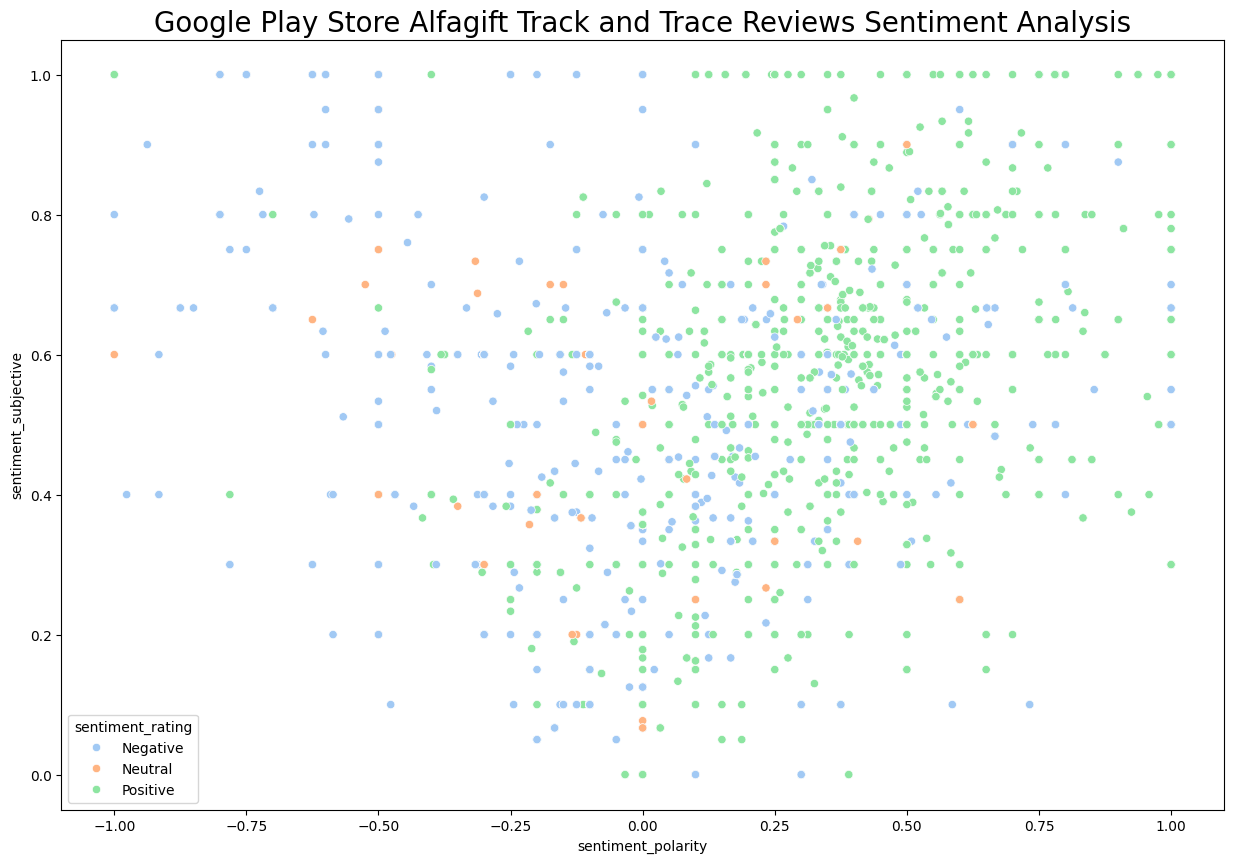

In [ ]:
plt.figure(figsize=(15, 10))
sns.scatterplot(x=df_alfagiftrev['sentiment_polarity'], y=df_alfagiftrev['sentiment_subjective'],
                hue = df_alfagiftrev['sentiment_rating'], edgecolor='white', palette="pastel")
plt.title("Google Play Store Alfagift Track and Trace Reviews Sentiment Analysis", fontsize=20)
plt.show()

## **8. Penghapusan Stopword**

Stopwords adalah kata-kata umum yang memiliki sedikit makna semantik (seperti 'dan', 'ini'). Daftar stopword NLTK bahasa Indonesia dan Inggris digabungkan dengan kata-kata informal tambahan untuk membersihkan kolom `content_cleaned` lebih lanjut.

In [ ]:
try:
    stopwords.words('indonesian')
except LookupError:
    nltk.download('stopwords')

stop = stopwords.words('english') + ["someone","still","would","need", "gak", "ga", "yg", "aja", "nya", "gk" ,",", "."]
stop.extend(stopwords.words('indonesian'))
print(stop)
print(len(stop))

df_alfagiftrev['content_cleaned'] = df_alfagiftrev['content_cleaned'].apply(lambda x: ' '.join([word for word in x.split() if word not in (stop)]))

['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an', 'and', 'any', 'are', 'aren', "aren't", 'as', 'at', 'be', 'because', 'been', 'before', 'being', 'below', 'between', 'both', 'but', 'by', 'can', 'couldn', "couldn't", 'd', 'did', 'didn', "didn't", 'do', 'does', 'doesn', "doesn't", 'doing', 'don', "don't", 'down', 'during', 'each', 'few', 'for', 'from', 'further', 'had', 'hadn', "hadn't", 'has', 'hasn', "hasn't", 'have', 'haven', "haven't", 'having', 'he', "he'd", "he'll", 'her', 'here', 'hers', 'herself', "he's", 'him', 'himself', 'his', 'how', 'i', "i'd", 'if', "i'll", "i'm", 'in', 'into', 'is', 'isn', "isn't", 'it', "it'd", "it'll", "it's", 'its', 'itself', "i've", 'just', 'll', 'm', 'ma', 'me', 'mightn', "mightn't", 'more', 'most', 'mustn', "mustn't", 'my', 'myself', 'needn', "needn't", 'no', 'nor', 'not', 'now', 'o', 'of', 'off', 'on', 'once', 'only', 'or', 'other', 'our', 'ours', 'ourselves', 'out', 'over', 'own', 're', 's', 'same', 'shan', "shan't", 'she

In [ ]:
pd.set_option('display.max_colwidth', None)
df_alfagiftrev_stopwords = df_alfagiftrev.loc[:,["content","content_cleaned","score","sentiment_polarity","review_length","sentiment_subjective","sentiment_rating","at"]]
display(df_alfagiftrev_stopwords.head(20))


,content,content_cleaned,score,sentiment_polarity,review_length,sentiment_subjective,sentiment_rating,at
0,parah sesi anda telah selesai ngapain coba keluara sendiri gak di gunaka juga,parah sesi selesai ngapain coba keluara gunaka,1,0.00,77,0.00,Negative,2026-03-30 13:39:27
1,tolong pihak alfamart sediakan jual rokok,tolong alfamart sediakan jual rokok,2,0.00,41,0.00,Negative,2026-03-30 13:33:37
2,ini gaada menu cancel orderan kah,gaada menu cancel orderan kah,3,0.00,33,0.00,Neutral,2026-03-30 13:11:09
3,percuma ada chat aplikasi kalo gapernah dibaca mending kek klik idm toko ada no wa buat kurir lonjakan ga kira2 estimasi jam 1 sampe jam 8 setengah 8 blm dikirim dan gabisa dihubungi chat toko,chat aplikasi gapernah dibaca mending klik idm toko wa kurir lonjakan kira2 estimasi jam 1 sampe jam 8 8 dikirim gabisa dihubungi chat toko,1,0.00,192,0.00,Negative,2026-03-30 12:57:09
4,udah nyaman eh alfamart nya pindah jadi jauh seharusnya 1 jam pembayaran ini nunggu 4 jam,udah nyaman eh alfamart pindah 1 jam pembayaran nunggu 4 jam,2,0.00,89,0.00,Negative,2026-03-30 12:46:39
5,sangat bagus bagi kami,bagus,5,0.00,23,0.00,Positive,2026-03-30 12:18:04
6,bintang bicara,bintang bicara,5,0.00,14,0.00,Positive,2026-03-30 11:49:19
7,customer service apaan pelayanan sangat buruk,customer service pelayanan buruk,1,0.00,45,0.00,Negative,2026-03-30 10:09:05
8,kerenn,kerenn,5,0.00,6,0.00,Positive,2026-03-30 08:12:15
9,barang tidak diterima nyasar entah disimpan dimana no alfanya tidak aktif chat di akun alfagift tidak dibalaskecewa sudah buat laporan ke callcenter alfagift dengan no laporan 3537578 tapi tidak ada tindak lanjut,barang diterima nyasar disimpan dimana alfanya aktif chat akun alfagift dibalaskecewa laporan callcenter alfagift laporan 3537578 tindak,1,0.00,213,0.00,Negative,2026-03-30 07:23:51


## **9. Tokenisasi Kata**

Proses memecah kalimat menjadi potongan kata individual (token). Kita menggunakan `nltk.word_tokenize` untuk memproses kolom `content_cleaned` menjadi daftar kata dalam kolom baru `word_tokenize`.

In [ ]:
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')
from nltk.tokenize import word_tokenize

# Pastikan tipe data string dan lakukan tokenisasi
df_alfagiftrev_stopwords['word_tokenize'] = df_alfagiftrev_stopwords['content_cleaned'].apply(lambda x: word_tokenize(str(x)))

# Tampilkan hasil
display(df_alfagiftrev_stopwords[['content_cleaned', 'word_tokenize']].head(10))

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


,content_cleaned,word_tokenize
0,parah sesi selesai ngapain coba keluara gunaka,"[parah, sesi, selesai, ngapain, coba, keluara, gunaka]"
1,tolong alfamart sediakan jual rokok,"[tolong, alfamart, sediakan, jual, rokok]"
2,gaada menu cancel orderan kah,"[gaada, menu, cancel, orderan, kah]"
3,chat aplikasi gapernah dibaca mending klik idm toko wa kurir lonjakan kira2 estimasi jam 1 sampe jam 8 8 dikirim gabisa dihubungi chat toko,"[chat, aplikasi, gapernah, dibaca, mending, klik, idm, toko, wa, kurir, lonjakan, kira2, estimasi, jam, 1, sampe, jam, 8, 8, dikirim, gabisa, dihubungi, chat, toko]"
4,udah nyaman eh alfamart pindah 1 jam pembayaran nunggu 4 jam,"[udah, nyaman, eh, alfamart, pindah, 1, jam, pembayaran, nunggu, 4, jam]"
5,bagus,[bagus]
6,bintang bicara,"[bintang, bicara]"
7,customer service pelayanan buruk,"[customer, service, pelayanan, buruk]"
8,kerenn,[kerenn]
9,barang diterima nyasar disimpan dimana alfanya aktif chat akun alfagift dibalaskecewa laporan callcenter alfagift laporan 3537578 tindak,"[barang, diterima, nyasar, disimpan, dimana, alfanya, aktif, chat, akun, alfagift, dibalaskecewa, laporan, callcenter, alfagift, laporan, 3537578, tindak]"


## **10. Perhitungan Jumlah Kata dan Pengecekan Kualitas Data**

Menghitung jumlah kata sebelum dan sesudah penghapusan stopword untuk melihat efektivitas pembersihan, serta mengecek apakah ada ulasan yang menjadi kosong setelah diproses.

In [ ]:
# 1. Menghitung jumlah kata setelah stopword removal
df_alfagiftrev_stopwords['wordCount'] = [len(str(review).split()) for review in df_alfagiftrev_stopwords['content']]
df_alfagiftrev_stopwords['wordCount_after_stopwords'] = [len(str(review).split()) for review in df_alfagiftrev_stopwords['content_cleaned']]

# 2. Cek ulasan yang menjadi kosong
empty_reviews = df_alfagiftrev_stopwords[df_alfagiftrev_stopwords['content_cleaned'].str.strip() == '']
print(f"Jumlah ulasan kosong setelah preprocessing: {len(empty_reviews)}")

# 3. Statistik ringkasan
stats = df_alfagiftrev_stopwords[['wordCount', 'wordCount_after_stopwords']].describe()
print("\nRingkasan Statistik Jumlah Kata:")
display(stats)



Jumlah ulasan kosong setelah preprocessing: 4949

Ringkasan Statistik Jumlah Kata:


,wordCount,wordCount_after_stopwords
count,170732.000000,170732.000000
mean,10.478967,6.302146
std,13.518501,7.695784
min,0.000000,0.000000
25%,2.000000,2.000000
50%,6.000000,4.000000
75%,13.000000,8.000000
max,134.000000,101.000000


## **11. Visualisasi: Kata yang Paling Sering Muncul**

Menampilkan grafik batang dari kata-kata yang paling sering muncul (frekuensi tertinggi) dalam ulasan yang telah dibersihkan untuk memahami topik utama pengguna.

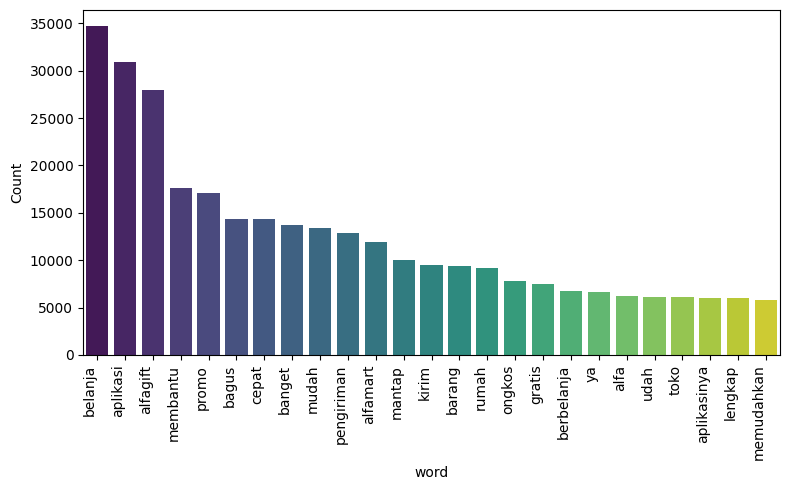

In [ ]:
# function to plot most frequent terms
def freq_words(x, terms = 25):
  all_words = ' '.join([text for text in x])
  all_words = all_words.split()

  fdist = FreqDist(all_words)
  words_df = pd.DataFrame({'word':list(fdist.keys()), 'count':list(fdist.values())})

  # selecting top `terms` most frequent words, which controls the number of words on the x-axis
  d = words_df.nlargest(columns="count", n = terms)
  plt.figure(figsize=(8,5))
  ax = sns.barplot(data=d, x= "word", y = "count", hue="word", legend=False, palette="viridis")
  ax.set(ylabel = 'Count')
  plt.xticks(rotation=90, ha='right') # Rotate x-axis labels for better readability
  plt.tight_layout() # Adjust layout to prevent labels from being cut off
  plt.show()

freq_words(df_alfagiftrev_stopwords['content_cleaned'])

## **12. Menyimpan Data Hasil Preprocessing**

Dataset yang telah melalui seluruh tahap pembersihan dan preprocessing disimpan ke dalam file CSV baru bernama `df_alfagiftrev_preprocessing.csv`.

In [ ]:
#Save into csv after applying stopwords
df_alfagiftrev_stopwords.to_csv(r'df_alfagiftrev_preprocessing.csv', index = False)